## **Question 1** 
**Generate spikes for 10 s (or longer if you want better statistics) using
a Poisson spike generator with a constant rate of 100 Hz, and record
their times of occurrence. Compute the coefficient of variation of the
interspike intervals, and the Fano factor for spike counts obtained
over counting intervals ranging from 1 to 100 ms. Plot the interspike
interval histogram.**

### Generating the Poisson Spike Sequence
A Poisson spike sequence is generated with the following formula: $$\Delta t = \frac{-\ln{x_{rand}}}{r} \tag{eq 1}$$ where "r" is the rate of the underlying distribution.

In [39]:
###Importing libraries###
import numpy as np
import matplotlib.pyplot as plt

###Setting variables###
r = 100.0 #underlying rate of distribution, in Hertz
times = [0.0] #list of time values, each corresponding to a spike
T = 10.0 #length of spike sequence generated, in seconds

###Creating list of spikes###
def find_delta_t(x_rand, rate):
    return -1*(np.log(x_rand)) / rate #finding delta_t according to (eq 1)

while times[-1] <= T: #Limiting the spike sequence to a certain time limit, defined by "T"
    #creating a spike at the previous time + delta_t
    times.append(times[-1] + find_delta_t(np.random.rand(), r)) 

#deleting the 0.0 at the start of the array and the last value, which is past T seconds
times = times[1:-1] 

### Plotting the Interspike Interval Histogram

(0.0, 100.0)

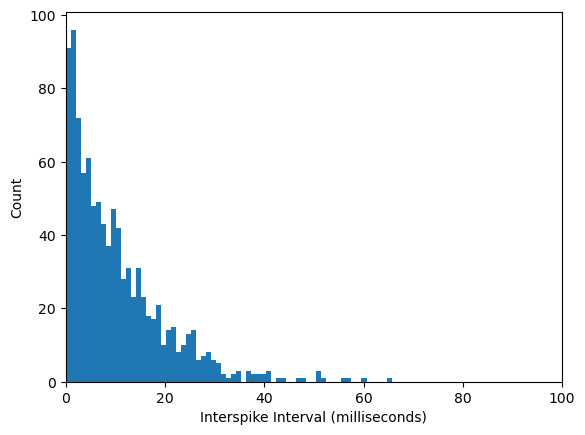

In [40]:
ISI = [] #creating an empty array for the interspike intervals

#iterating through every spike to calculate the time to the next spike
for i in range(len(times) - 1):
    ISI.append((times[i + 1] - times[i]) * 1000) #multiplying by 1000 to convert from s to ms


plt.hist(ISI, bins=99, range=(0,100))
plt.xlabel("Interspike Interval (milliseconds)")
plt.ylabel("Count")
plt.xlim(0,100)

### Calculating Coefficient of Variation & Fano Factor
Coefficient of variation of a Poisson process is calculated via the standard deviation divided by the mean of the interspike interval distribution. \
\
Fano factor of a Poisson process is calculated via the variance divided by the mean of the spike count distribution. \
\
Thus, for any renewal process, the Fano factor should approach the square of the coefficient of variation.

In [41]:
C_v = np.std(ISI) / np.mean(ISI) #Calculating coefficient of variation
print(f"Coefficient of variation: {C_v}")

#Calculating Fano factor
bin_sizes = [0.001, 0.01, 0.1]  # 1, 10, 100 ms bins
for i in bin_sizes:
    counts, _ = np.histogram(times, bins=np.arange(0, T + i, i))
    print(f"Fano Factor for bins of {i * 1000} ms: {np.var(counts) / np.mean(counts)}")

Coefficient of variation: 0.9520527852094637
Fano Factor for bins of 1.0 ms: 1.0052585365853655
Fano Factor for bins of 10.0 ms: 0.9204715447154472
Fano Factor for bins of 100.0 ms: 0.6823577235772357


## **Question 2**
**Add a refractory period to the Poisson spike generator by allowing the firing rate to depend on time. Initially, set the firing rate to a constant value, $r(t) = r_0$. After every spike, set $r(t)$ to 0, and then allow it to recover exponentially back to $r_0$ with a time constant $\tau_{ref}$ that controls the refractory recovery rate. In other words, have $r(t)$ obey the equation $$\tau_{\text{ref}} \frac{dr}{dt} = r_0 - r$$ except immediately after a spike, when it is set to 0. Plot the coefficient of variation as a function of $\tau_{ref}$ over the range 1 ms $\le \tau_{ref} \le$ 20 ms, and plot interspike interval histograms for a few different values of $\tau_{ref}$ in this range. Compute the Fano factor for spike counts obtained over counting intervals ranging from 1 to 100 ms for the case $\tau_{ref}$ = 10 ms.**

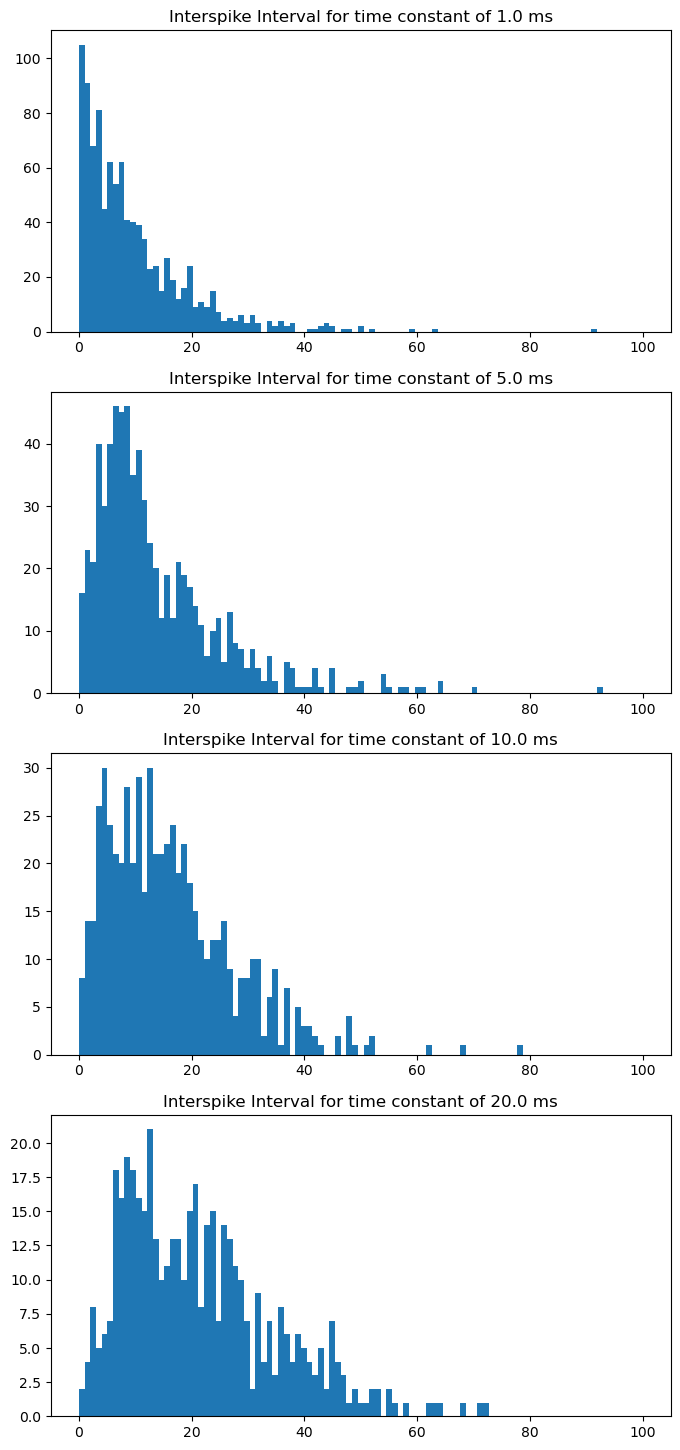

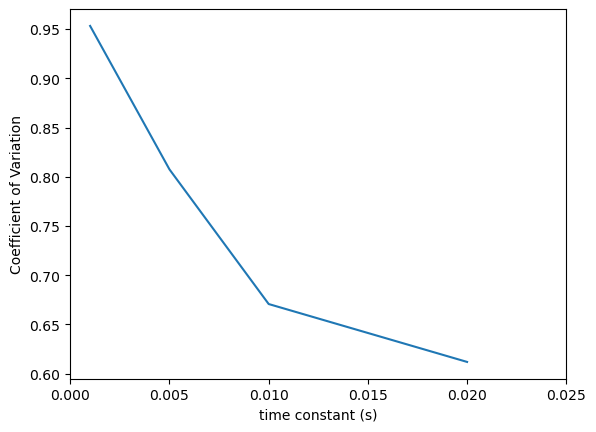

Fano Factor for bins of 1.0 ms: 0.9395000000000003 
Fano Factor for bins of 10.0 ms: 0.6892148760330578 
Fano Factor for bins of 100.0 ms: 0.3483471074380165 



In [42]:
refracted_times = []
coefficients_variation = []
time_constants = [0.001, 0.005, 0.01, 0.02]
dt = 0.001
fano_output = ""

fig, plots = plt.subplots(4,1, figsize=(8,18))

refracted_times_10 = [] #used for Question 3 later, not relevant for this question

for num in range(len(plots)):
    tau_ref = time_constants[num]
    refracted_times = []
    current_rate = r 

    for t in np.arange(0, T, dt):
        # rate recovery
        current_rate += (r - current_rate) * (dt / tau_ref)

        # probability of spike
        if np.random.rand() < current_rate * dt:
            refracted_times.append(t)
            current_rate = 0

    if tau_ref == 0.01:
        refracted_times_10 = refracted_times
        bin_sizes = [0.001, 0.01, 0.1]  # 1, 10, 100 ms bins
        for i in bin_sizes:
            counts, _ = np.histogram(refracted_times, bins=np.arange(0, T + i, i))
            fano_output += f"Fano Factor for bins of {i * 1000} ms: {np.var(counts) / np.mean(counts)} \n"  
        
    # compute ISI
    if len(refracted_times) > 1:
        ISI = np.diff(refracted_times) * 1000
    else:
        ISI = []

    plots[num].hist(ISI, bins=99, range=(0,100))
    plots[num].set_title(f"Interspike Interval for time constant of {tau_ref * 1000} ms")

    if len(ISI) > 0:
        coefficients_variation.append(np.std(ISI) / np.mean(ISI))
    else:
        coefficients_variation.append(0)

plt.figure()
plt.plot(time_constants, coefficients_variation)
plt.xlabel("time constant (s)")
plt.ylabel("Coefficient of Variation")
plt.xlim(0,0.025)
plt.show()

print(fano_output)

## Question 3
**Compute autocorrelation histograms of spike trains generated by a Poisson generator with a constant firing rate of 100 Hz, a constant firing rate of 100 Hz together with a refractory period modeled as in exercise 2 with $\tau_{ref}$ = 10 ms, and a variable firing rate: $$r(t) = 100(1 + cos(2{\bf \pi}t/25 \text{ ms})) \text{ Hz}$$Plot the histograms over a range from 0 to 100 ms.**

### Autocorrelation Function
The autocorrelation function is formally defined as $$Q_{pp}(\tau) = \frac{1}{T}\int_0^T dt \langle (\rho (t) - \langle r \rangle)(\rho (t + \tau) - \langle r \rangle) \rangle \tag{eq 2}$$ Which ends up simplifying to an average of products of the differences between the rates at every pair of spikes. This question, however, only asks for the autocorrelation histograms, meaning the only thing to be computed is the product of the differences.
\
\
Additionally, when programming, the function must be discretized, and when a delta function of spikes is used as an input, the autocorrelation function simplifies to the mean of differences between all spikes (including a spike and itself).

In [43]:
def autocorrelation_histogram(spikes):
    autocorrelation_intervals = []
    for spike1 in spikes:
        for spike2 in spikes:
            autocorrelation_intervals.append(np.abs(spike2 - spike1))
    return autocorrelation_intervals        

#### Poisson Generator of Constant Rate

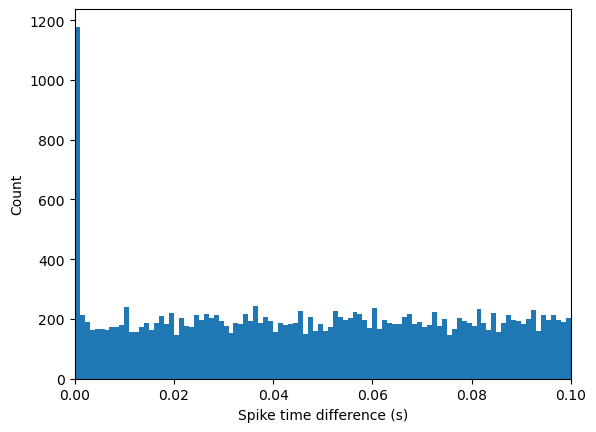

In [44]:
#Refer to Q1 for generation of "times" as a constant-rate Poisson process
plt.figure()
plt.hist(autocorrelation_histogram(times), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

The spike at 0ms is caused by the relative majority of comparisons between spikes being between the spike and itself, yielding a difference of 0. Because the coefficient of variation of a constant-rate Poisson process is close to 1, there is little variation between the spike time differences. Additionally, the baseline (around 200 in the graph above) is equal to: $$\frac{N^2 \Delta t}{T}, N \approx rT \tag{eq 3}$$ Thus, the expected value per histogram for our calculation is $\frac{(100*10)^2 * 0.001}{10} = 100$, but since the question asked for a histogram range from 0 to 100 ms, the absolute value of the difference was taken, meaning all negative values were effectively moved onto their positive counterparts, doubling the bin count, explaining the observed graph.

#### Poisson Generator of Refractory Rate

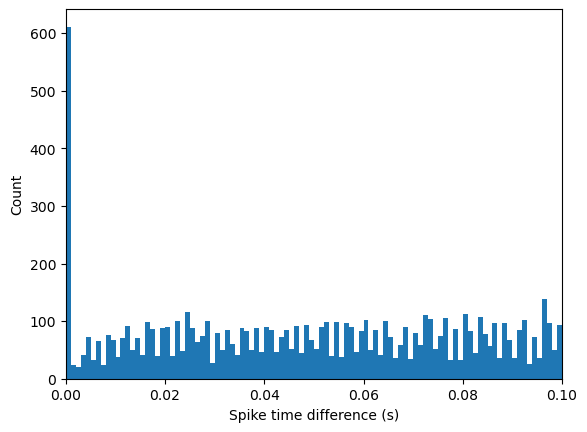

In [45]:
#Refer to Q2 for generation of "refracted_times_10" as a refractory-rate Poisson process
plt.figure()
plt.hist(autocorrelation_histogram(refracted_times_10), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

A Poisson generated spike train with a refractory period shows a similar  graph, but the time constant means the spike time difference is a jagged graph due to the refractory period creating a "cool-off" for refiring.

#### Poisson Generator of Variable Firing Rate

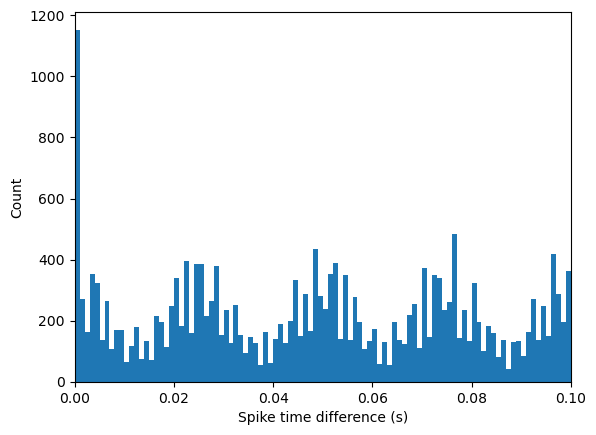

In [52]:
variable_spikes = []
for time in np.arange(0, T, dt):
    rate = 100 * (1 + np.cos(2*np.pi*time / 0.025))
    if np.random.rand() < rate * dt:
        variable_spikes.append(time)

plt.figure()
plt.hist(autocorrelation_histogram(variable_spikes), bins=100, range=(0, 0.1))
plt.xlim(0, 0.1)
plt.xlabel("Spike time difference (s)")
plt.ylabel("Count")
plt.show()

Finally, for a spike generation process that is sinusoidal in nature, the oscillations of the approximate curves give an indication that there is a rhythmic pattern to the spike train.